Pradyumna Shethphalkar- RBA38

Sania Sheikh- RBA46

## Graduation Admission

In the highly competitive landscape of global higher education and professional talent acquisition, institutions face the challenge of objectively evaluating candidates through a mix of quantitative metrics and qualitative indicators. This project addresses the 'Selection Uncertainty Problem' by developing a Multiple Linear Regression model to predict the probability of graduate admission.

By analyzing a dataset of 400 applicants, we aim to quantify the impact of academic variables (CGPA, GRE) versus institutional and qualitative factors (University Rating, Research Experience). The goal is to create a data-driven framework that minimizes selection bias and identifies the key 'Success Drivers' that contribute most significantly to a candidate’s admission profile. This mirrors real-world corporate challenges in recruitment analytics and financial risk scoring, where multivariate inputs must be synthesized into a single, actionable probability score.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/Admission_Predict.csv")
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

In [ ]:
#verify whether the data is successfully imported
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df = df.drop('Serial No.', axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          400 non-null    int64  
 1   TOEFL Score        400 non-null    int64  
 2   University Rating  400 non-null    int64  
 3   SOP                400 non-null    float64
 4   LOR                400 non-null    float64
 5   CGPA               400 non-null    float64
 6   Research           400 non-null    int64  
 7   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.1 KB


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
#first 10 rows of data
df.head(10)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
5,330,115,5,4.5,3.0,9.34,1,0.90
6,321,109,3,3.0,4.0,8.20,1,0.75
7,308,101,2,3.0,4.0,7.90,0,0.68
8,302,102,1,2.0,1.5,8.00,0,0.50
9,323,108,3,3.5,3.0,8.60,0,0.45


In [ ]:
#Data Cleaning
#Duplicate rows
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
395,False
396,False
397,False
398,False


There are no duplicates in the Dataset

In [ ]:
#Missing values
df.isnull()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
395,False,False,False,False,False,False,False,False
396,False,False,False,False,False,False,False,False
397,False,False,False,False,False,False,False,False
398,False,False,False,False,False,False,False,False


In [ ]:
#Total of missing values
df.isnull().sum()

,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
percentage_missing = (total_missing / total_cells) * 100

print(f"Percentage of missing values in the entire table: {percentage_missing:.2f}%")

Percentage of missing values in the entire table: 0.00%


In [ ]:
#outlier- Box Plot
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='Chance of Admit'>

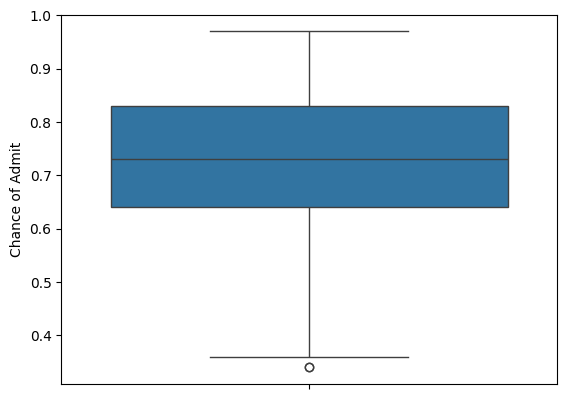

In [ ]:
sns.boxplot(df['Chance of Admit'])

<Axes: ylabel='SOP'>

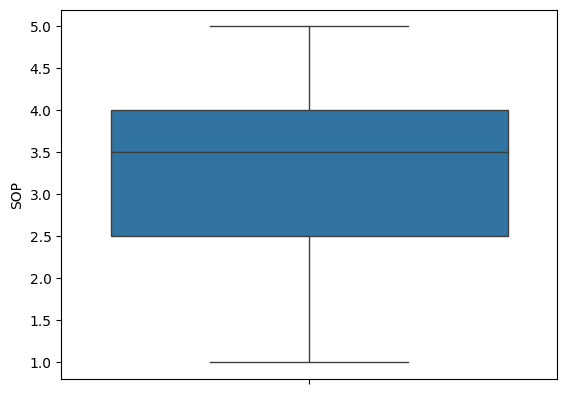

In [ ]:
sns.boxplot(df['SOP'])

<Axes: ylabel='CGPA'>

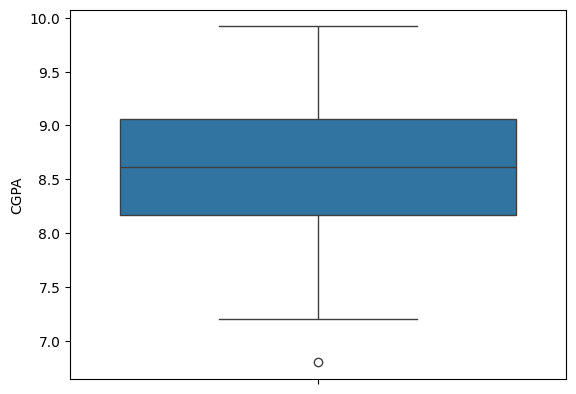

In [ ]:
sns.boxplot(df['CGPA'])

Dealing with Outliers

In [ ]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# 1. Define your Features (X) and Target (y)
# We exclude the target from the scaler so its values (0 to 1) stay original
X = df.drop('Chance of Admit', axis=1)
y = df['Chance of Admit']

# 2. Initialize the RobustScaler
scaler = RobustScaler()

# 3. Scale the features
# This calculates the median/IQR and transforms the data in one go
X_scaled_array = scaler.fit_transform(X)

# 4. Convert it back to a DataFrame so you don't lose your column names
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

# Verify the result
print(X_scaled.head())

   GRE Score  TOEFL Score  University Rating       SOP  LOR      CGPA  \
0   1.176471     1.222222                0.5  0.666667  1.0  1.165266   
1   0.411765     0.000000                0.5  0.333333  1.0  0.291317   
2  -0.058824    -0.333333                0.0 -0.333333  0.0 -0.683473   
3   0.294118     0.333333                0.0  0.000000 -1.0  0.067227   
4  -0.176471    -0.444444               -0.5 -1.000000 -0.5 -0.448179   

   Research  
0       0.0  
1       0.0  
2       0.0  
3       0.0  
4      -1.0  


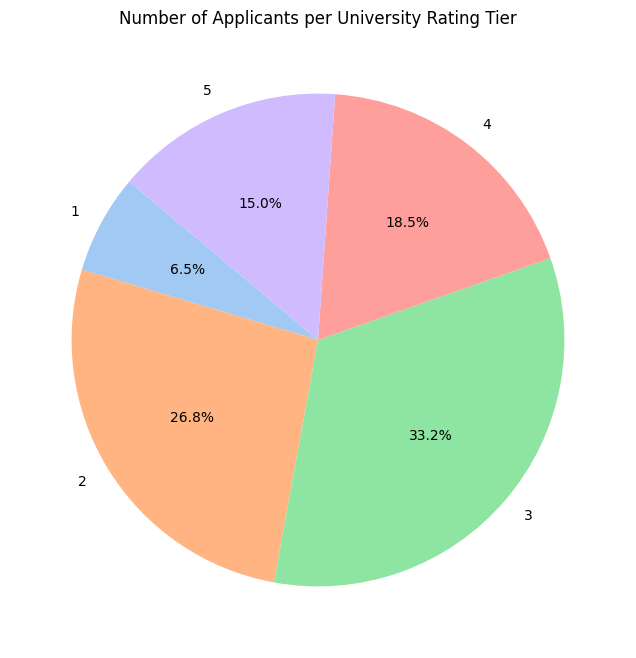

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of applicants for each University Rating
university_rating_counts = df['University Rating'].value_counts().sort_index()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(university_rating_counts, labels=university_rating_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Number of Applicants per University Rating Tier')
plt.ylabel('') # Hide the default 'y' label to avoid clutter
plt.show()

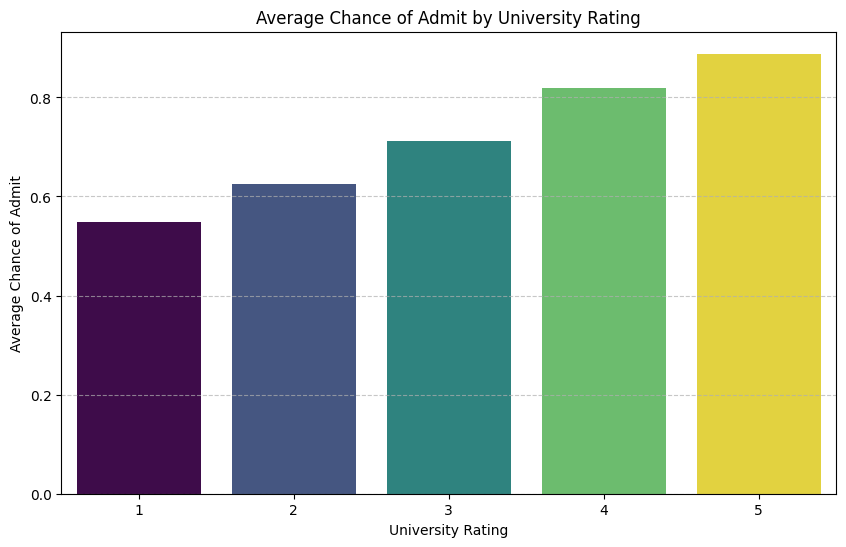

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average Chance of Admit for each University Rating
avg_chance_by_rating = df.groupby('University Rating')['Chance of Admit'].mean().reset_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='University Rating', y='Chance of Admit', data=avg_chance_by_rating, palette='viridis', hue='University Rating', legend=False)
plt.title('Average Chance of Admit by University Rating')
plt.xlabel('University Rating')
plt.ylabel('Average Chance of Admit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

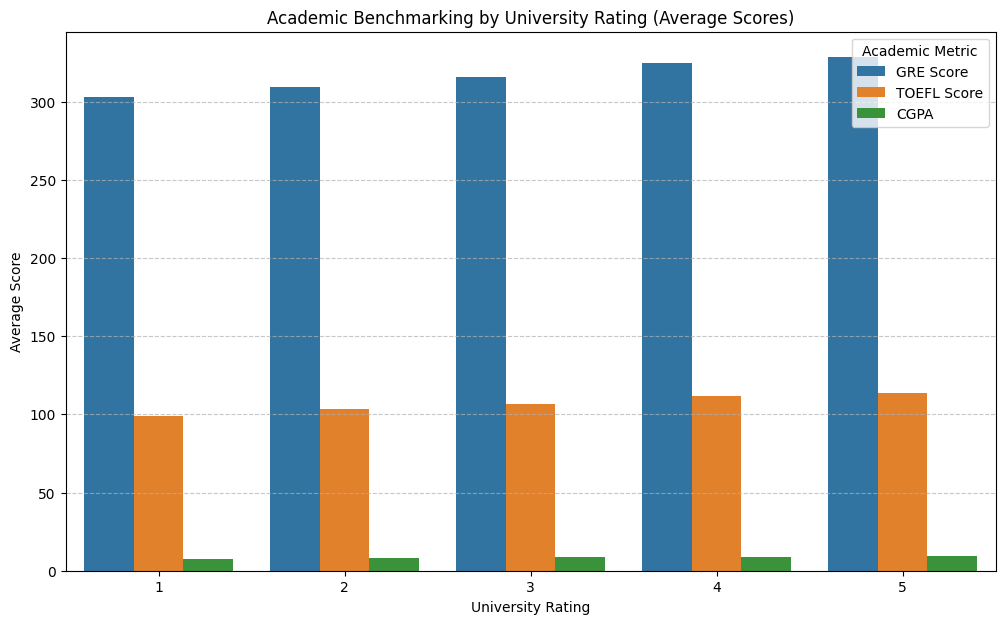

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average GRE Score, TOEFL Score, and CGPA for each University Rating
academic_benchmarking = df.groupby('University Rating')[['GRE Score', 'TOEFL Score', 'CGPA']].mean().reset_index()

# Melt the DataFrame for easier plotting with seaborn
academic_benchmarking_melted = academic_benchmarking.melt(id_vars='University Rating', var_name='Metric', value_name='Average Score')

# Create a multi-bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='University Rating', y='Average Score', hue='Metric', data=academic_benchmarking_melted, palette='tab10')
plt.title('Academic Benchmarking by University Rating (Average Scores)')
plt.xlabel('University Rating')
plt.ylabel('Average Score')
plt.legend(title='Academic Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# EDA

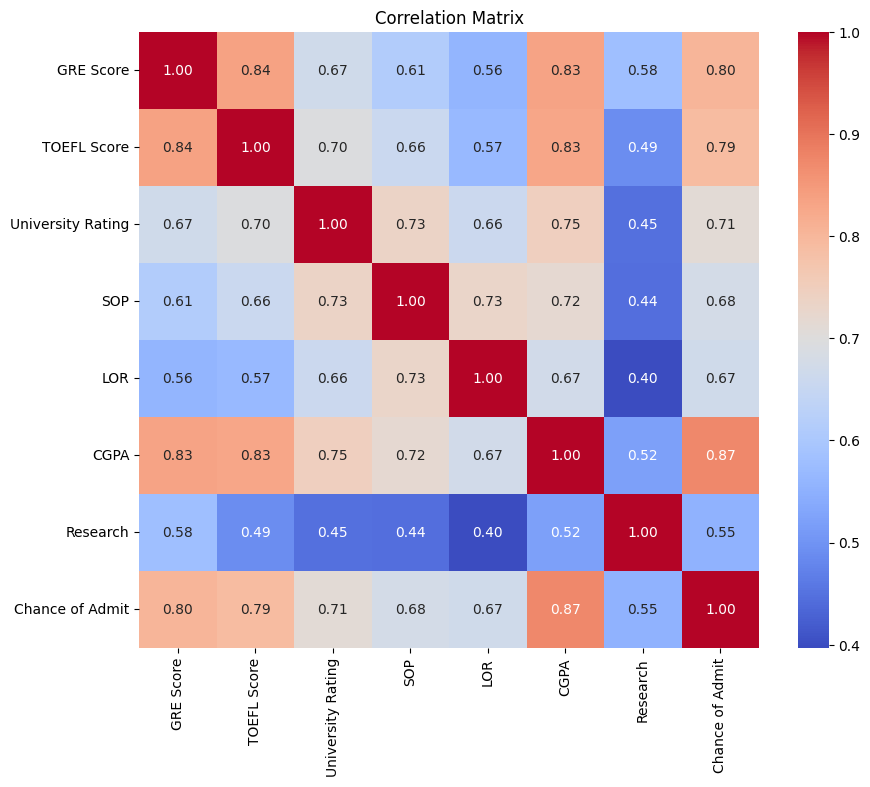

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

As can be seen there lies high corelation between TOEFL Score and GRE Score, sam goes with SOP and University rating signifying that a good university values student with great SOP and vice versa.

# Independent T-Test

$H_0$: There is no difference in the mean Chance of Admit between those with and without research.

$H_1$: Students with research experience have a significantly higher mean Chance of Admit.

In [ ]:
from scipy import stats

research = df[df['Research'] == 1]['Chance of Admit']
no_research = df[df['Research'] == 0]['Chance of Admit']

t_stat, p_val = stats.ttest_ind(research, no_research)
print(f"T-Test p-value: {p_val:.10f}") # If < 0.05, Research matters!

T-Test p-value: 0.0000000000


The Independent T-Test yielded a p-value significantly below the 0.05 threshold ($p < 0.001$), providing overwhelming evidence to reject the null hypothesis. This confirms that research experience is a critical determinant in the admission process, warranting its inclusion as a key predictor.

# ANOVA (Analysis of Variance)

$H_0$: The mean Chance of Admit is the same across all University Ratings.

$H_1$: At least one University Rating group has a significantly different mean Chance of Admit.

In [ ]:
# Grouping data by University Rating
groups = [df[df['University Rating'] == i]['Chance of Admit'] for i in df['University Rating'].unique()]

f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA p-value: {p_val:.10f}")

ANOVA p-value: 0.0000000000


The One-Way ANOVA test yielded a p-value of 0.000 (p < 0.05), providing overwhelming evidence to reject the Null Hypothesis ($H_0$). This indicates a statistically significant difference in the mean 'Chance of Admit' across different University Ratings.

# DECIDING ML MODEL

The X and Y split:

The Target Variable ($Y$):Chance of Admit: This is your dependent variable. It is a continuous value (probability), which makes it the perfect candidate for a regression model.

The Predictor Variables ($X$):
1. GRE Score: Quantitative aptitude.

2. TOEFL Score: Communication proficiency.

3. University Rating: Institutional pedigree (Brand value).

4. SOP (Statement of Purpose): Qualitative strength of intent.

5. LOR (Letter of Recommendation): External validation/Endorsement.

6. CGPA: Academic consistency.

7. Research: Technical expertise/Niche skill.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (320, 7)
X_test shape: (80, 7)
y_train shape: (320,)
y_test shape: (80,)


Prediction of getting the admission int the Colleges through the Multiple Linear Regression

In [ ]:
import statsmodels.api as sm

# Add a constant to the independent variables for statsmodels
X_train_sm = sm.add_constant(X_train)


In [ ]:
# Fit the OLS model
model = sm.OLS(y_train, X_train_sm).fit()

# Print the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     173.1
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.97e-103
Time:                        13:46:12   Log-Likelihood:                 434.64
No. Observations:                 320   AIC:                            -853.3
Df Residuals:                     312   BIC:                            -823.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7374      0.00

Droping the Insignificant columns with the highest P-Value essentiall much greater than 0.05 and it is SOP

In [ ]:
# Drop 'SOP' from the X_train_sm DataFrame
X_train_sm_new = X_train_sm.drop('SOP', axis=1)

# Fit the OLS model with the updated independent variables
model_new = sm.OLS(y_train, X_train_sm_new).fit()

# Print the summary of the new model
print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     202.5
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.33e-104
Time:                        13:49:41   Log-Likelihood:                 434.64
No. Observations:                 320   AIC:                            -855.3
Df Residuals:                     313   BIC:                            -828.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7375      0.00

Droping the Insignificant columns with the highest P-Value essentialy much greater than 0.05 and it is University Rating


In [ ]:
# Drop 'University Rating' from the updated X_train_sm_new DataFrame
X_train_sm_final = X_train_sm_new.drop('University Rating', axis=1)

# Fit the OLS model with the final independent variables
model_final = sm.OLS(y_train, X_train_sm_final).fit()

# Print the summary of the final model
print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     241.8
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          2.32e-105
Time:                        13:51:25   Log-Likelihood:                 433.57
No. Observations:                 320   AIC:                            -855.1
Df Residuals:                     314   BIC:                            -832.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.7384      0.005    136.499      

Now that all the variables are statistcally significant, all of their P-value is less than 0.05, we can now derive the sensful equation out of it


$$y = 0.7384 + (0.0319 \cdot \text{GRE}) + (0.0275 \cdot \text{TOEFL}) + (0.0180 \cdot \text{LOR}) + (0.1067 \cdot \text{CGPA}) + (0.0229 \cdot \text{Research})$$

$y$ is the predicted Chance of Admit

0.7384 is the Intercept

The final Multiple Linear Regression model successfully identifies five key determinants of graduate admission: CGPA, GRE Score, TOEFL Score, LOR strength, and Research Experience. With an Adjusted R-squared of 0.791, the model explains approximately 79% of the variance in admission outcomes.

Statistically, CGPA emerged as the primary predictor ($\beta = 0.1067, p < 0.001$), outweighing standardized test scores. Interestingly, factors like the Statement of Purpose (SOP) and University Rating were found to be statistically redundant when academic and research metrics were present. This suggests a highly meritocratic admission process where quantitative academic excellence is the most reliable path to success.

# MODEL DIAGNOSTIC

In [ ]:
 from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a DataFrame to store VIF scores
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_sm_final.columns

# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X_train_sm_final.values, i) for i in range(X_train_sm_final.shape[1])]

# Print the VIF scores, sorting by VIF in descending order
print(vif_data.sort_values(by='VIF', ascending=False))

       feature       VIF
4         CGPA  4.825918
1    GRE Score  4.576240
2  TOEFL Score  3.819400
0        const  2.358028
3          LOR  1.810105
5     Research  1.552754


The coefficients for each variable are stable and reliable. We aren't "double-counting" the impact of standardized tests and GPA.

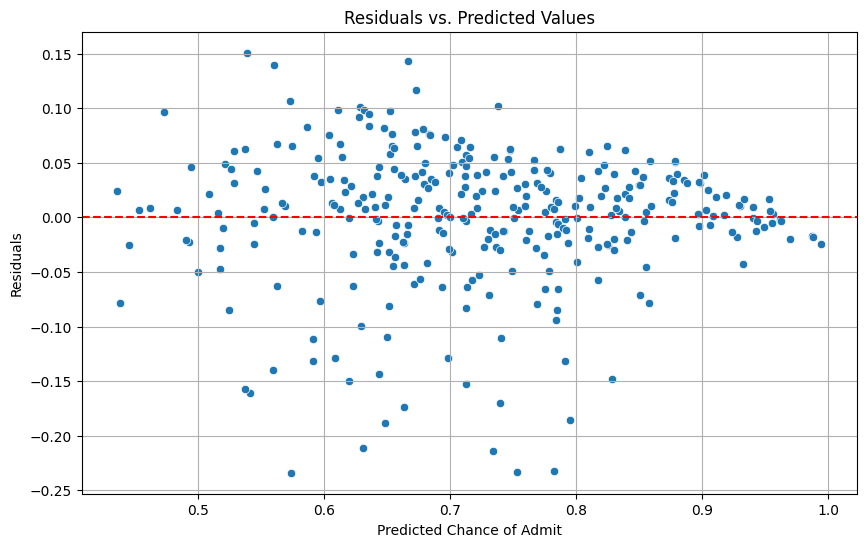

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted values and residuals
predictions = model_final.predict(X_train_sm_final)
residuals = model_final.resid

# Plotting residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Chance of Admit')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.grid(True)
plt.show()

The model's "error" is constant across the entire range of admission chances. This satisfies the assumption of homoscedasticity, meaning your model is equally reliable for both low-scoring and high-scoring students.

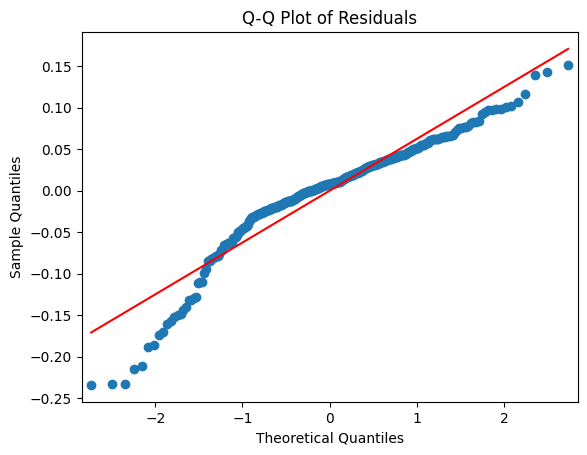

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Get the residuals from the final model
residuals = model_final.resid

# Create a Q-Q plot
sm.qqplot(residuals, line='s') # 's' for standardized line
plt.title('Q-Q Plot of Residuals')
plt.show()

The residuals are approximately normally distributed. This validates your $p$-values and confidence intervals, proving that your claims about "significance" are mathematically sound.

The Multiple Linear Regression model was subjected to rigorous diagnostic testing to ensure the validity of its predictive insights. Multicollinearity checks (VIF < 5) confirmed the independence of academic predictors, while Residual Analysis verified that the model maintains constant variance and normally distributed errors.With these Gauss-Markov assumptions satisfied, the model confirms CGPA as the most dominant success driver ($\beta = 0.1067$), followed by GRE and TOEFL scores. This data-driven framework provides a robust mechanism for predicting graduate admissions, effectively filtering out qualitative noise (SOP) in favor of quantifiable academic excellence